# Heat budget analysis
In this notebook:
- heat budget (fixed footprint)
- peak-temperature-tendency
- warming-peak/cooling-peak composites
- positive-tendency only check
- fixed vs. time-varying footprint comparison for the heat budget

## Imports

In [33]:
# Imports
import xarray as xr
import numpy as np
import pandas as pd
import json
import pickle
import os
import time
import importlib
import xesmf as xe
import matplotlib.pyplot as plt
import analysis_functions as afuncs
importlib.reload(afuncs)

<module 'analysis_functions' from '/glade/u/home/cassiacai/measures/analysis_functions.py'>

## Functions

In [9]:
def detrend_term(da):
    term_nan = xr.where(da == 0., np.nan, da) * NO_SEC_IN_1_MON
    mean, trend, seasonal, notrend = afuncs.calculate_pop_grid_anomalies_trend_features(term_nan)
    return notrend

In [10]:
def build_padded_time_window(full_time_index, event_times, pre_post_months=2):
    first_idx = int(np.where(full_time_index.values == event_times.values[0])[0][0])
    last_idx = int(np.where(full_time_index.values == event_times.values[-1])[0][0])
    pad_start = max(0, first_idx - pre_post_months)
    pad_end = min(len(full_time_index) - 1, last_idx + pre_post_months)
    return full_time_index.isel(time=slice(pad_start, pad_end + 1))

In [11]:
# Phase-splitting: magnitude-based (primary) and positive-only-forced (robustness check)
def phase_split_adaptive(term_profiles, pre_post_months=2, min_months_for_5phase=8):
    """Peak-tendency = month of max |TEND_TEMP| within core window (magnitude-based)."""
    tend_temp = term_profiles['TEND_TEMP']
    n_total = len(tend_temp.time)
    core_start = pre_post_months
    core_end = n_total - pre_post_months
    core_length = core_end - core_start

    if core_length < min_months_for_5phase:
        result = {}
        for term, ts in term_profiles.items():
            result[term] = {
                'Pre-MHW':  float(ts.isel(time=slice(0, core_start)).mean()),
                'detection': float(ts.isel(time=slice(core_start, core_end)).mean()),
                'Post-MHW': float(ts.isel(time=slice(-pre_post_months, None)).mean()),
            }
        return result, 3, None

    core_tend = tend_temp.isel(time=slice(core_start, core_end))
    peak_idx_within_core = int(np.abs(core_tend.values).argmax())
    peak_idx_global = core_start + peak_idx_within_core
    has_prepeak = peak_idx_global > core_start
    has_postpeak = peak_idx_global < core_end - 1

    result = {}
    for term, ts in term_profiles.items():
        result[term] = {
            'Pre-MHW':  float(ts.isel(time=slice(0, core_start)).mean()),
            'pre-peak': float(ts.isel(time=slice(core_start, peak_idx_global)).mean()) if has_prepeak else np.nan,
            'peak-tendency': float(ts.isel(time=peak_idx_global)),
            'post-peak': float(ts.isel(time=slice(peak_idx_global + 1, core_end)).mean()) if has_postpeak else np.nan,
            'Post-MHW': float(ts.isel(time=slice(-pre_post_months, None)).mean()),
        }
    peak_date = tend_temp.time.values[peak_idx_global]
    return result, 5, peak_date

In [12]:
def phase_split_positive_only(term_profiles, pre_post_months=2, min_months_for_5phase=8):
    """Peak-tendency FORCED to max POSITIVE TEND_TEMP (robustness check vs. magnitude-based)."""
    tend_temp = term_profiles['TEND_TEMP']
    n_total = len(tend_temp.time)
    core_start = pre_post_months
    core_end = n_total - pre_post_months
    core_length = core_end - core_start

    if core_length < min_months_for_5phase:
        return None, 3, None

    core_tend = tend_temp.isel(time=slice(core_start, core_end))
    peak_idx_within_core = int(core_tend.values.argmax())
    peak_idx_global = core_start + peak_idx_within_core
    has_prepeak = peak_idx_global > core_start
    has_postpeak = peak_idx_global < core_end - 1

    result = {}
    for term, ts in term_profiles.items():
        result[term] = {
            'Pre-MHW':  float(ts.isel(time=slice(0, core_start)).mean()),
            'pre-peak': float(ts.isel(time=slice(core_start, peak_idx_global)).mean()) if has_prepeak else np.nan,
            'peak-tendency': float(ts.isel(time=peak_idx_global)),
            'post-peak': float(ts.isel(time=slice(peak_idx_global + 1, core_end)).mean()) if has_postpeak else np.nan,
            'Post-MHW': float(ts.isel(time=slice(-pre_post_months, None)).mean()),
        }
    peak_date = tend_temp.time.values[peak_idx_global]
    return result, 5, peak_date

In [13]:
def separate_peak_by_sign(keys, hb_phases_dict):
    warming_keys, cooling_keys = [], []
    for key in keys:
        tend_peak = hb_phases_dict[key]['phases']['TEND_TEMP']['peak-tendency']
        if np.isnan(tend_peak):
            continue
        (warming_keys if tend_peak > 0 else cooling_keys).append(key)
    return warming_keys, cooling_keys

In [14]:
def composite_phase_group(keys, hb_phases_dict, phase_names):
    composite = {term: {p: [] for p in phase_names} for term in TERMS}
    for key in keys:
        phases = hb_phases_dict[key]['phases']
        for term in composite:
            for p in phase_names:
                val = phases[term].get(p, np.nan)
                if not np.isnan(val):
                    composite[term][p].append(val)
    result = {}
    for term, phase_dict in composite.items():
        result[term] = {}
        for p, vals in phase_dict.items():
            arr = np.array(vals)
            mean = np.nanmean(arr) if len(arr) > 0 else np.nan
            std = np.nanstd(arr) if len(arr) > 0 else np.nan
            result[term][p] = (mean, std, len(arr))
    return result

In [15]:
def get_individual_values_by_phase(keys, hb_phases_dict, term, phase_names):
    result = {p: [] for p in phase_names}
    for key in keys:
        phases = hb_phases_dict[key]['phases']
        for p in phase_names:
            val = phases[term].get(p, np.nan)
            if not np.isnan(val):
                result[p].append(val)
    return result

In [16]:
# Per-member heat budget processing (canonical footprint)
def load_lens_heat_budget_full(member_id):
    ds_terms = xr.open_dataset(
        f'/glade/derecho/scratch/cmendiola/heat_budget_blob_fosi_lens2_paper/heat_budget_{member_id}_03172026.nc'
    )
    ds_tend = xr.open_dataset(
        f'/glade/derecho/scratch/cmendiola/heat_budget_blob_fosi_lens2_paper/heat_budget_onlytemptend_{member_id}_07242026.nc'
    )
    return xr.merge([ds_terms, ds_tend])

In [17]:
def process_one_member_heat_budget(member_id, labels_full, analog_ids_for_member, NEPac_mask):
    if not analog_ids_for_member:
        return {}
    hb_raw = load_lens_heat_budget_full(member_id)
    hb_raw['SUBGRID'] = hb_raw['TEND_TEMP'] - (hb_raw['TOT_ADV'] + hb_raw['SHF_depth'] + hb_raw['QSW_3D'])
    hb_detrended = {term: detrend_term(hb_raw[term]) for term in TERMS}
    hb_cropped = {term: da.isel(nlat_t=lat_slice, nlon_t=lon_slice) for term, da in hb_detrended.items()}
    hb_masked = {term: da.where(NEPac_mask == 1) for term, da in hb_cropped.items()}
    member_labels = labels_full.isel(ensemble_member=member_id)
    member_profiles = {}
    for analog_id in analog_ids_for_member:
        key = (member_id, analog_id)
        mask = (member_labels == analog_id)
        times_present = member_labels.time.where(mask.any(dim=('lat', 'lon')), drop=True)
        if len(times_present) == 0:
            continue
        padded_times = build_padded_time_window(member_labels.time, times_present)
        term_profiles = {
            term: da.sel(time=padded_times).mean(dim=('nlat_t', 'nlon_t')).compute()
            for term, da in hb_masked.items()
        }
        member_profiles[key] = {
            'terms': term_profiles,
            'season': pd.Timestamp(str(times_present.values[0])).month,
        }
    print(f"Member {member_id} done")
    return member_profiles

In [22]:
def build_labels_to_pop_regridder(labels_grid_da, pop_target_grid_ds_cropped, method='nearest_s2d'):
    ds_in = xr.Dataset(coords={'lat': labels_grid_da.lat.values, 'lon': labels_grid_da.lon.values})
    ds_out = xr.Dataset(coords={
        'lat': (('nlat_t', 'nlon_t'), pop_target_grid_ds_cropped.TLAT.values),
        'lon': (('nlat_t', 'nlon_t'), pop_target_grid_ds_cropped.TLONG.values),
    })
    return xe.Regridder(ds_in, ds_out, method, periodic=True)

In [23]:
def build_time_varying_mask_for_analog(member_labels, analog_id, times_present, regridder):
    mask_lat_lon = (member_labels.sel(time=times_present) == analog_id).astype(float)
    mask_pop_grid = regridder(mask_lat_lon)
    return xr.where(mask_pop_grid > 0.5, 1, 0)

In [24]:
def process_one_member_heat_budget_timevarying(member_id, labels_full, analog_ids_for_member, regridder):
    if not analog_ids_for_member:
        return {}
    hb_raw = load_lens_heat_budget_full(member_id)
    hb_raw['SUBGRID'] = hb_raw['TEND_TEMP'] - (hb_raw['TOT_ADV'] + hb_raw['SHF_depth'] + hb_raw['QSW_3D'])
    hb_detrended = {term: detrend_term(hb_raw[term]) for term in TERMS}
    hb_cropped = {term: da.isel(nlat_t=lat_slice, nlon_t=lon_slice) for term, da in hb_detrended.items()}
    member_labels = labels_full.isel(ensemble_member=member_id)
    member_profiles = {}
    for analog_id in analog_ids_for_member:
        key = (member_id, analog_id)
        mask = (member_labels == analog_id)
        times_present = member_labels.time.where(mask.any(dim=('lat', 'lon')), drop=True)
        if len(times_present) == 0:
            continue
        padded_times = build_padded_time_window(member_labels.time, times_present)
        time_varying_mask = build_time_varying_mask_for_analog(member_labels, analog_id, times_present, regridder)
        term_profiles = {}
        for term, da in hb_cropped.items():
            da_padded = da.sel(time=padded_times)
            masked_active = da_padded.sel(time=times_present).where(time_varying_mask.sel(time=times_present) == 1)
            first_mask = time_varying_mask.isel(time=0)
            last_mask = time_varying_mask.isel(time=-1)
            pre_times = padded_times[~padded_times.isin(times_present) & (padded_times < times_present[0])]
            post_times = padded_times[~padded_times.isin(times_present) & (padded_times > times_present[-1])]
            masked_pre = da_padded.sel(time=pre_times).where(first_mask == 1) if len(pre_times) > 0 else None
            masked_post = da_padded.sel(time=post_times).where(last_mask == 1) if len(post_times) > 0 else None
            pieces = [p for p in [masked_pre, masked_active, masked_post] if p is not None]
            full_masked = xr.concat(pieces, dim='time').sortby('time')
            term_profiles[term] = full_masked.mean(dim=('nlat_t', 'nlon_t')).compute()
        member_profiles[key] = {'terms': term_profiles, 'season': pd.Timestamp(str(times_present.values[0])).month}
    print(f"Member {member_id} done (time-varying)")
    return member_profiles

In [29]:
def get_original_footprint_sizes(member_id, analog_id, labels_full):
    member_labels = labels_full.isel(ensemble_member=member_id)
    mask = (member_labels == analog_id)
    times_present = member_labels.time.where(mask.any(dim=('lat', 'lon')), drop=True)
    if len(times_present) == 0:
        return None
    return mask.sel(time=times_present).sum(dim=('lat', 'lon')).values

In [44]:
def plot_term_panel_violin_with_blob(ax, term, phase_names, keys, hb_phases_dict, blob_values, title, color, ylim=(-9, 9)):
    individual_vals = get_individual_values_by_phase(keys, hb_phases_dict, term, phase_names)
    data_for_violin = [individual_vals[p] for p in phase_names]
    positions = np.arange(len(phase_names))

    parts = ax.violinplot(data_for_violin, positions=positions, showmeans=True, showmedians=False, widths=0.7)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
        pc.set_edgecolor('k')
        pc.set_linewidth(0.8)
    parts['cmeans'].set_color('red')
    parts['cmeans'].set_linewidth(2)
    parts['cbars'].set_color('k')
    parts['cmins'].set_color('k')
    parts['cmaxes'].set_color('k')

    for i, phase in enumerate(phase_names):
        val = blob_values.get(phase, np.nan)
        if not np.isnan(val):
            ax.scatter(i, val, color='gold', edgecolor='black', s=180,
                       marker='*', zorder=20, linewidth=1.2, label='CESM2-FOSI Blob' if i == 0 else None)

    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_xticks(positions)
    ax.set_xticklabels(phase_names, fontsize=11, rotation=25, ha='right')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim(ylim)
    ax.tick_params(axis='y', labelsize=12)
    ax.tick_params(axis='x', labelsize=12)

## Constants

In [5]:
# Constants
lat_slice = slice(204, 367)
lon_slice = slice(190, 280)
NO_SEC_IN_1_MON = 2629740

## Load data

In [4]:
base_paths = {
    'linear':    '/glade/work/cmendiola/data_conv_lin_trend',
    'quadratic': '/glade/work/cmendiola/data_quad_trend',
    'ensmean':   '/glade/work/cmendiola/data_ens_mean',
    'noseas':    '/glade/work/cmendiola/data_rm_seasonalcycle_mean',
}
RADIUS_INDEX_FOR_2DEG = 1
OVERLAP_THRESHOLD_INDEX = 4  # 50%

TERMS = ['TEND_TEMP', 'TOT_ADV', 'SHF_depth', 'QSW_3D', 'SUBGRID']
PHASE_NAMES_5 = ['Pre-MHW', 'pre-peak', 'peak-tendency', 'post-peak', 'Post-MHW']

da_mhwobj_labels_by_method = {}
for method, base_path in base_paths.items():
    mhwobj_paths = [f'{base_path}/ens_{i}_mhwobj.nc' for i in range(100)]
    da_mhwobj = xr.open_mfdataset(mhwobj_paths, combine='nested', concat_dim='ensemble_member')
    da_mhwobj_labels_by_method[method] = (
        da_mhwobj.labels.sel(radius=RADIUS_INDEX_FOR_2DEG).sel(time=slice('1979-01', '2020-12')).compute()
    )
labels_full = da_mhwobj_labels_by_method['linear']
print("Labels loaded:", {m: da_mhwobj_labels_by_method[m].sizes for m in base_paths})

blob_analog_ids = {}
object_id_json_paths = {
    'linear':    'object_id_ls_greenmask_linear_corrected.json',
    'quadratic': 'object_id_ls_greenmask_quadratic_corrected.json',
    'ensmean':   'object_id_ls_greenmask_ensmean_corrected.json',
    'noseas':    'object_id_ls_greenmask_noseas_corrected.json',
}
for method, path in object_id_json_paths.items():
    with open(path, 'r') as f:
        all_thresholds = json.load(f)
    blob_analog_ids[method] = all_thresholds[OVERLAP_THRESHOLD_INDEX]
print({m: sum(len(v) for v in blob_analog_ids[m]) for m in blob_analog_ids}, "-- VERIFY: linear 331")

Labels loaded: {'linear': Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81}), 'quadratic': Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81}), 'ensmean': Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81}), 'noseas': Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81})}
{'linear': 331, 'quadratic': 327, 'ensmean': 312, 'noseas': 343} -- VERIFY: linear 331


In [6]:
# The Blob in FOSI
fosi_blobs = xr.open_dataset('fosi_blobs_r2.nc').labels
object_id = 94.0
blob_times = fosi_blobs.time.where((fosi_blobs == object_id).any(dim=('lat', 'lon')), drop=True)
print(f"n_months in blob_times: {len(blob_times)} -- VERIFY: 20")

n_months in blob_times: 20 -- VERIFY: 20


In [7]:
# Canonical mask
mean_image_pop_files = [f'/glade/derecho/scratch/cassiacai/mean_image_{i}_POP.nc' for i in range(1, 8)]
mean_images_pop = [xr.open_dataset(file) for file in mean_image_pop_files]
masks_pop = [xr.where(image.__xarray_dataarray_variable__ > 0.1, 1, 0) for image in mean_images_pop]
NEPac_MHW_renamed_latlon = masks_pop[2].isel(nlat=lat_slice, nlon=lon_slice).rename({'nlat': 'nlat_t', 'nlon': 'nlon_t'})

## Analysis

### FOSI Blob

In [35]:
fosi_heat_budget = xr.open_dataset('/glade/derecho/scratch/cassiacai/fosi_heat_budget_155m.nc')
fosi_heat_budget['SUBGRID'] = fosi_heat_budget['TEND_TEMP'] - (
    fosi_heat_budget['TOTADV'] + fosi_heat_budget['SHF_depth'] + fosi_heat_budget['QSW_3D']
)
fosi_hb_detrended = {}
for term in ['TOTADV', 'SHF_depth', 'QSW_3D', 'SUBGRID', 'TEND_TEMP']:
    notrend = detrend_term(fosi_heat_budget[term])
    key = 'TOT_ADV' if term == 'TOTADV' else term
    fosi_hb_detrended[key] = notrend
fosi_hb_cropped = {term: da.isel(nlat_t=lat_slice, nlon_t=lon_slice) for term, da in fosi_hb_detrended.items()}

fosi_hb_masked = {term: da.where(NEPac_MHW_renamed_latlon == 1) for term, da in fosi_hb_cropped.items()}

padded_times_fosi = build_padded_time_window(fosi_hb_masked['TOT_ADV'].time, blob_times)
fosi_hb_profile = {
    term: da.sel(time=padded_times_fosi).mean(dim=('nlat_t', 'nlon_t')).compute()
    for term, da in fosi_hb_masked.items()
}

fosi_phases_5, fosi_n_phases, fosi_peak_date = phase_split_adaptive(fosi_hb_profile)
print(f"\nFOSI Blob: {fosi_n_phases}-phase, peak = {str(fosi_peak_date)[:7]} -- VERIFY: 5-phase, 2015-01")


FOSI Blob: 5-phase, peak = 2015-01 -- VERIFY: 5-phase, 2015-01


### Fixed footprint 

In [ ]:
# SAVE HEAT BUDGET
# output_dir_hb = '/glade/derecho/scratch/cassiacai/heat_budget_profiles_by_member'
# os.makedirs(output_dir_hb, exist_ok=True)
# for member_id in range(100):
#     save_path = f'{output_dir_hb}/member_{member_id}.pkl'
#     if os.path.exists(save_path):
#         continue
#     member_profiles = process_one_member_heat_budget(
#         member_id, labels_full, blob_analog_ids['linear'][member_id], NEPac_MHW_renamed_latlon
#     )
#     with open(save_path, 'wb') as f:
#         pickle.dump(member_profiles, f)

In [ ]:
# Reload and build composites
output_dir_hb = '/glade/derecho/scratch/cassiacai/heat_budget_profiles_by_member'

heat_budget_profiles_all = {}
for member_id in range(100):
    save_path = f'{output_dir_hb}/member_{member_id}.pkl'
    if os.path.exists(save_path):
        with open(save_path, 'rb') as f:
            heat_budget_profiles_all.update(pickle.load(f))
print(f"Total analogs loaded: {len(heat_budget_profiles_all)} SHOULD BE: 331")

hb_phases_all = {}
for key, data in heat_budget_profiles_all.items():
    phases, n_phases, peak_date = phase_split_adaptive(data['terms'])
    hb_phases_all[key] = {'phases': phases, 'n_phases': n_phases, 'peak_date': peak_date}

keys_5phase = [k for k, v in hb_phases_all.items() if v['n_phases'] == 5]
warming_keys, cooling_keys = separate_peak_by_sign(keys_5phase, hb_phases_all)
print(f"5-phase: {len(keys_5phase)} -- VERIFY: 242")
print(f"Warming/Cooling: {len(warming_keys)}/{len(cooling_keys)} -- VERIFY: 113/129")

composite_all_5phase = composite_phase_group(keys_5phase, hb_phases_all, PHASE_NAMES_5)
composite_warming = composite_phase_group(warming_keys, hb_phases_all, PHASE_NAMES_5)
composite_cooling = composite_phase_group(cooling_keys, hb_phases_all, PHASE_NAMES_5)

In [19]:
# Check robustness: positive-tendency-forced composite (all 242, regardless of sign)
hb_phases_positive_only = {}
for key in keys_5phase:
    phases, n_phases, peak_date = phase_split_positive_only(heat_budget_profiles_all[key]['terms'])
    if phases is not None:
        hb_phases_positive_only[key] = {'phases': phases, 'n_phases': n_phases, 'peak_date': peak_date}
composite_positive_only = composite_phase_group(list(hb_phases_positive_only.keys()), hb_phases_positive_only, PHASE_NAMES_5)

# Boundary-case analysis: analogs missing pre-peak/post-peak, and duration bias check
prepeak_missing_warming = [k for k in warming_keys if np.isnan(hb_phases_all[k]['phases']['TEND_TEMP']['pre-peak'])]
postpeak_missing_cooling = [k for k in cooling_keys if np.isnan(hb_phases_all[k]['phases']['TEND_TEMP']['post-peak'])]
print(f"Missing pre-peak (warming): {len(prepeak_missing_warming)} / {len(warming_keys)}")
print(f"Missing post-peak (cooling): {len(postpeak_missing_cooling)} / {len(cooling_keys)}")

Missing pre-peak (warming): 28 / 113
Missing post-peak (cooling): 36 / 129


In [25]:
# Time-varying footprint sensitivity for heat budget
# Build regridder
pop_grid_ref = xr.open_dataset('/glade/derecho/scratch/cassiacai/mean_image_3_POP.nc')
pop_grid_ref_cropped = pop_grid_ref.isel(nlat=lat_slice, nlon=lon_slice).rename({'nlat': 'nlat_t', 'nlon': 'nlon_t'})
regridder = build_labels_to_pop_regridder(labels_full.isel(ensemble_member=0, time=0), pop_grid_ref_cropped)

In [26]:
# output_dir_hb_timevarying = '/glade/derecho/scratch/cassiacai/heat_budget_profiles_by_member_timevarying'
# os.makedirs(output_dir_hb_timevarying, exist_ok=True)
# for member_id in range(100):
#     save_path = f'{output_dir_hb_timevarying}/member_{member_id}.pkl'
#     if os.path.exists(save_path):
#         continue
#     member_profiles = process_one_member_heat_budget_timevarying(
#         member_id, labels_full, blob_analog_ids['linear'][member_id], regridder
#     )
#     with open(save_path, 'wb') as f:
#         pickle.dump(member_profiles, f)

### Time-varying footprint

In [27]:
output_dir_hb_timevarying = '/glade/derecho/scratch/cassiacai/heat_budget_profiles_by_member_timevarying'
heat_budget_profiles_timevarying = {}
for member_id in range(100):
    save_path = f'{output_dir_hb_timevarying}/member_{member_id}.pkl'
    if os.path.exists(save_path):
        with open(save_path, 'rb') as f:
            heat_budget_profiles_timevarying.update(pickle.load(f))

hb_phases_timevarying = {}
for key, data in heat_budget_profiles_timevarying.items():
    phases, n_phases, peak_date = phase_split_adaptive(data['terms'])
    hb_phases_timevarying[key] = {'phases': phases, 'n_phases': n_phases, 'peak_date': peak_date}

In [28]:
shared_keys = set(hb_phases_all.keys()) & set(hb_phases_timevarying.keys())
shifted_keys = []
for key in shared_keys:
    canon_peak = hb_phases_all[key]['peak_date']
    tv_peak = hb_phases_timevarying[key]['peak_date']
    if canon_peak is not None and tv_peak is not None and canon_peak != tv_peak:
        shifted_keys.append(key)
print(f"Analogs where peak-tendency MONTH differs: {len(shifted_keys)} / {len(shared_keys)}")


Analogs where peak-tendency MONTH differs: 179 / 331


In [30]:
max_ratios = []
for member_id, analog_id in shifted_keys:
    sizes = get_original_footprint_sizes(member_id, analog_id, labels_full)
    if sizes is None or len(sizes) < 2:
        continue
    ratios = sizes[1:] / np.maximum(sizes[:-1], 1)
    max_ratios.append(np.max(ratios))
max_ratios = np.array(max_ratios)
print(f"Analogs with >1.5x month-to-month footprint jump: {100*np.mean(max_ratios > 1.5):.1f}%")

Analogs with >1.5x month-to-month footprint jump: 93.9%


### Comparison

In [43]:
N_years = 100 * 42

print("Blob percentile at ALL phases, vs. positive-tendency-forced population (n=242)")
for phase in PHASE_NAMES_5:
    print(f"\n--- {phase} ---")
    for term in TERMS:
        blob_val = blob_values_all_phases[term][phase]
        if np.isnan(blob_val):
            print(f"  {term}: Blob value undefined")
            continue
        pop_vals = np.array(get_individual_values_by_phase(
            list(hb_phases_positive_only.keys()), hb_phases_positive_only, term, [phase]
        )[phase])
        pct = 100 * np.mean(pop_vals <= blob_val)
        p_exceed = np.mean(pop_vals >= blob_val)
        rp = N_years / (len(pop_vals) * p_exceed) if p_exceed > 0 else np.inf
        print(f"  {term}: Blob={blob_val:.2f}, n={len(pop_vals)}, percentile={pct:.1f}, RP={rp:.1f} yr")

Blob percentile at ALL phases, vs. positive-tendency-forced population (n=242)

--- Pre-MHW ---
  TEND_TEMP: Blob=0.15, n=242, percentile=38.0, RP=28.0 yr
  TOT_ADV: Blob=1.17, n=242, percentile=80.2, RP=87.5 yr
  SHF_depth: Blob=0.16, n=242, percentile=37.6, RP=27.8 yr
  QSW_3D: Blob=-0.24, n=242, percentile=12.8, RP=19.9 yr
  SUBGRID: Blob=-0.93, n=242, percentile=41.3, RP=29.6 yr

--- pre-peak ---
  TEND_TEMP: Blob=0.22, n=185, percentile=35.7, RP=35.3 yr
  TOT_ADV: Blob=0.14, n=185, percentile=39.5, RP=37.5 yr
  SHF_depth: Blob=0.46, n=185, percentile=42.7, RP=39.6 yr
  QSW_3D: Blob=0.10, n=185, percentile=32.4, RP=33.6 yr
  SUBGRID: Blob=-0.47, n=185, percentile=65.4, RP=65.6 yr

--- peak-tendency ---
  TEND_TEMP: Blob=2.49, n=242, percentile=83.1, RP=102.4 yr
  TOT_ADV: Blob=0.11, n=242, percentile=54.1, RP=37.8 yr
  SHF_depth: Blob=4.66, n=242, percentile=81.8, RP=95.5 yr
  QSW_3D: Blob=0.39, n=242, percentile=33.5, RP=26.1 yr
  SUBGRID: Blob=-2.66, n=242, percentile=46.3, RP=32

In [42]:
print("Blob percentile at ALL phases, vs. WARMING-PEAK ONLY population (n=113)")
for phase in PHASE_NAMES_5:
    print(f"\n--- {phase} ---")
    for term in TERMS:
        blob_val = blob_values_all_phases[term][phase]
        if np.isnan(blob_val):
            print(f"  {term}: Blob value undefined")
            continue
        pop_vals = np.array(get_individual_values_by_phase(
            warming_keys, hb_phases_all, term, [phase]
        )[phase])
        pct = 100 * np.mean(pop_vals <= blob_val)
        p_exceed = np.mean(pop_vals >= blob_val)
        rp = N_years / (len(pop_vals) * p_exceed) if p_exceed > 0 else np.inf
        print(f"  {term}: Blob={blob_val:.2f}, n={len(pop_vals)}, percentile={pct:.1f}, RP={rp:.1f} yr")

Blob percentile at ALL phases, vs. WARMING-PEAK ONLY population (n=113)

--- Pre-MHW ---
  TEND_TEMP: Blob=0.15, n=113, percentile=33.6, RP=56.0 yr
  TOT_ADV: Blob=1.17, n=113, percentile=82.3, RP=210.0 yr
  SHF_depth: Blob=0.16, n=113, percentile=36.3, RP=58.3 yr
  QSW_3D: Blob=-0.24, n=113, percentile=13.3, RP=42.9 yr
  SUBGRID: Blob=-0.93, n=113, percentile=41.6, RP=63.6 yr

--- pre-peak ---
  TEND_TEMP: Blob=0.22, n=85, percentile=31.8, RP=72.4 yr
  TOT_ADV: Blob=0.14, n=85, percentile=28.2, RP=68.9 yr
  SHF_depth: Blob=0.46, n=85, percentile=41.2, RP=84.0 yr
  QSW_3D: Blob=0.10, n=85, percentile=31.8, RP=72.4 yr
  SUBGRID: Blob=-0.47, n=85, percentile=69.4, RP=161.5 yr

--- peak-tendency ---
  TEND_TEMP: Blob=2.49, n=113, percentile=69.9, RP=123.5 yr
  TOT_ADV: Blob=0.11, n=113, percentile=60.2, RP=93.3 yr
  SHF_depth: Blob=4.66, n=113, percentile=68.1, RP=116.7 yr
  QSW_3D: Blob=0.39, n=113, percentile=40.7, RP=62.7 yr
  SUBGRID: Blob=-2.66, n=113, percentile=46.0, RP=68.9 yr

--

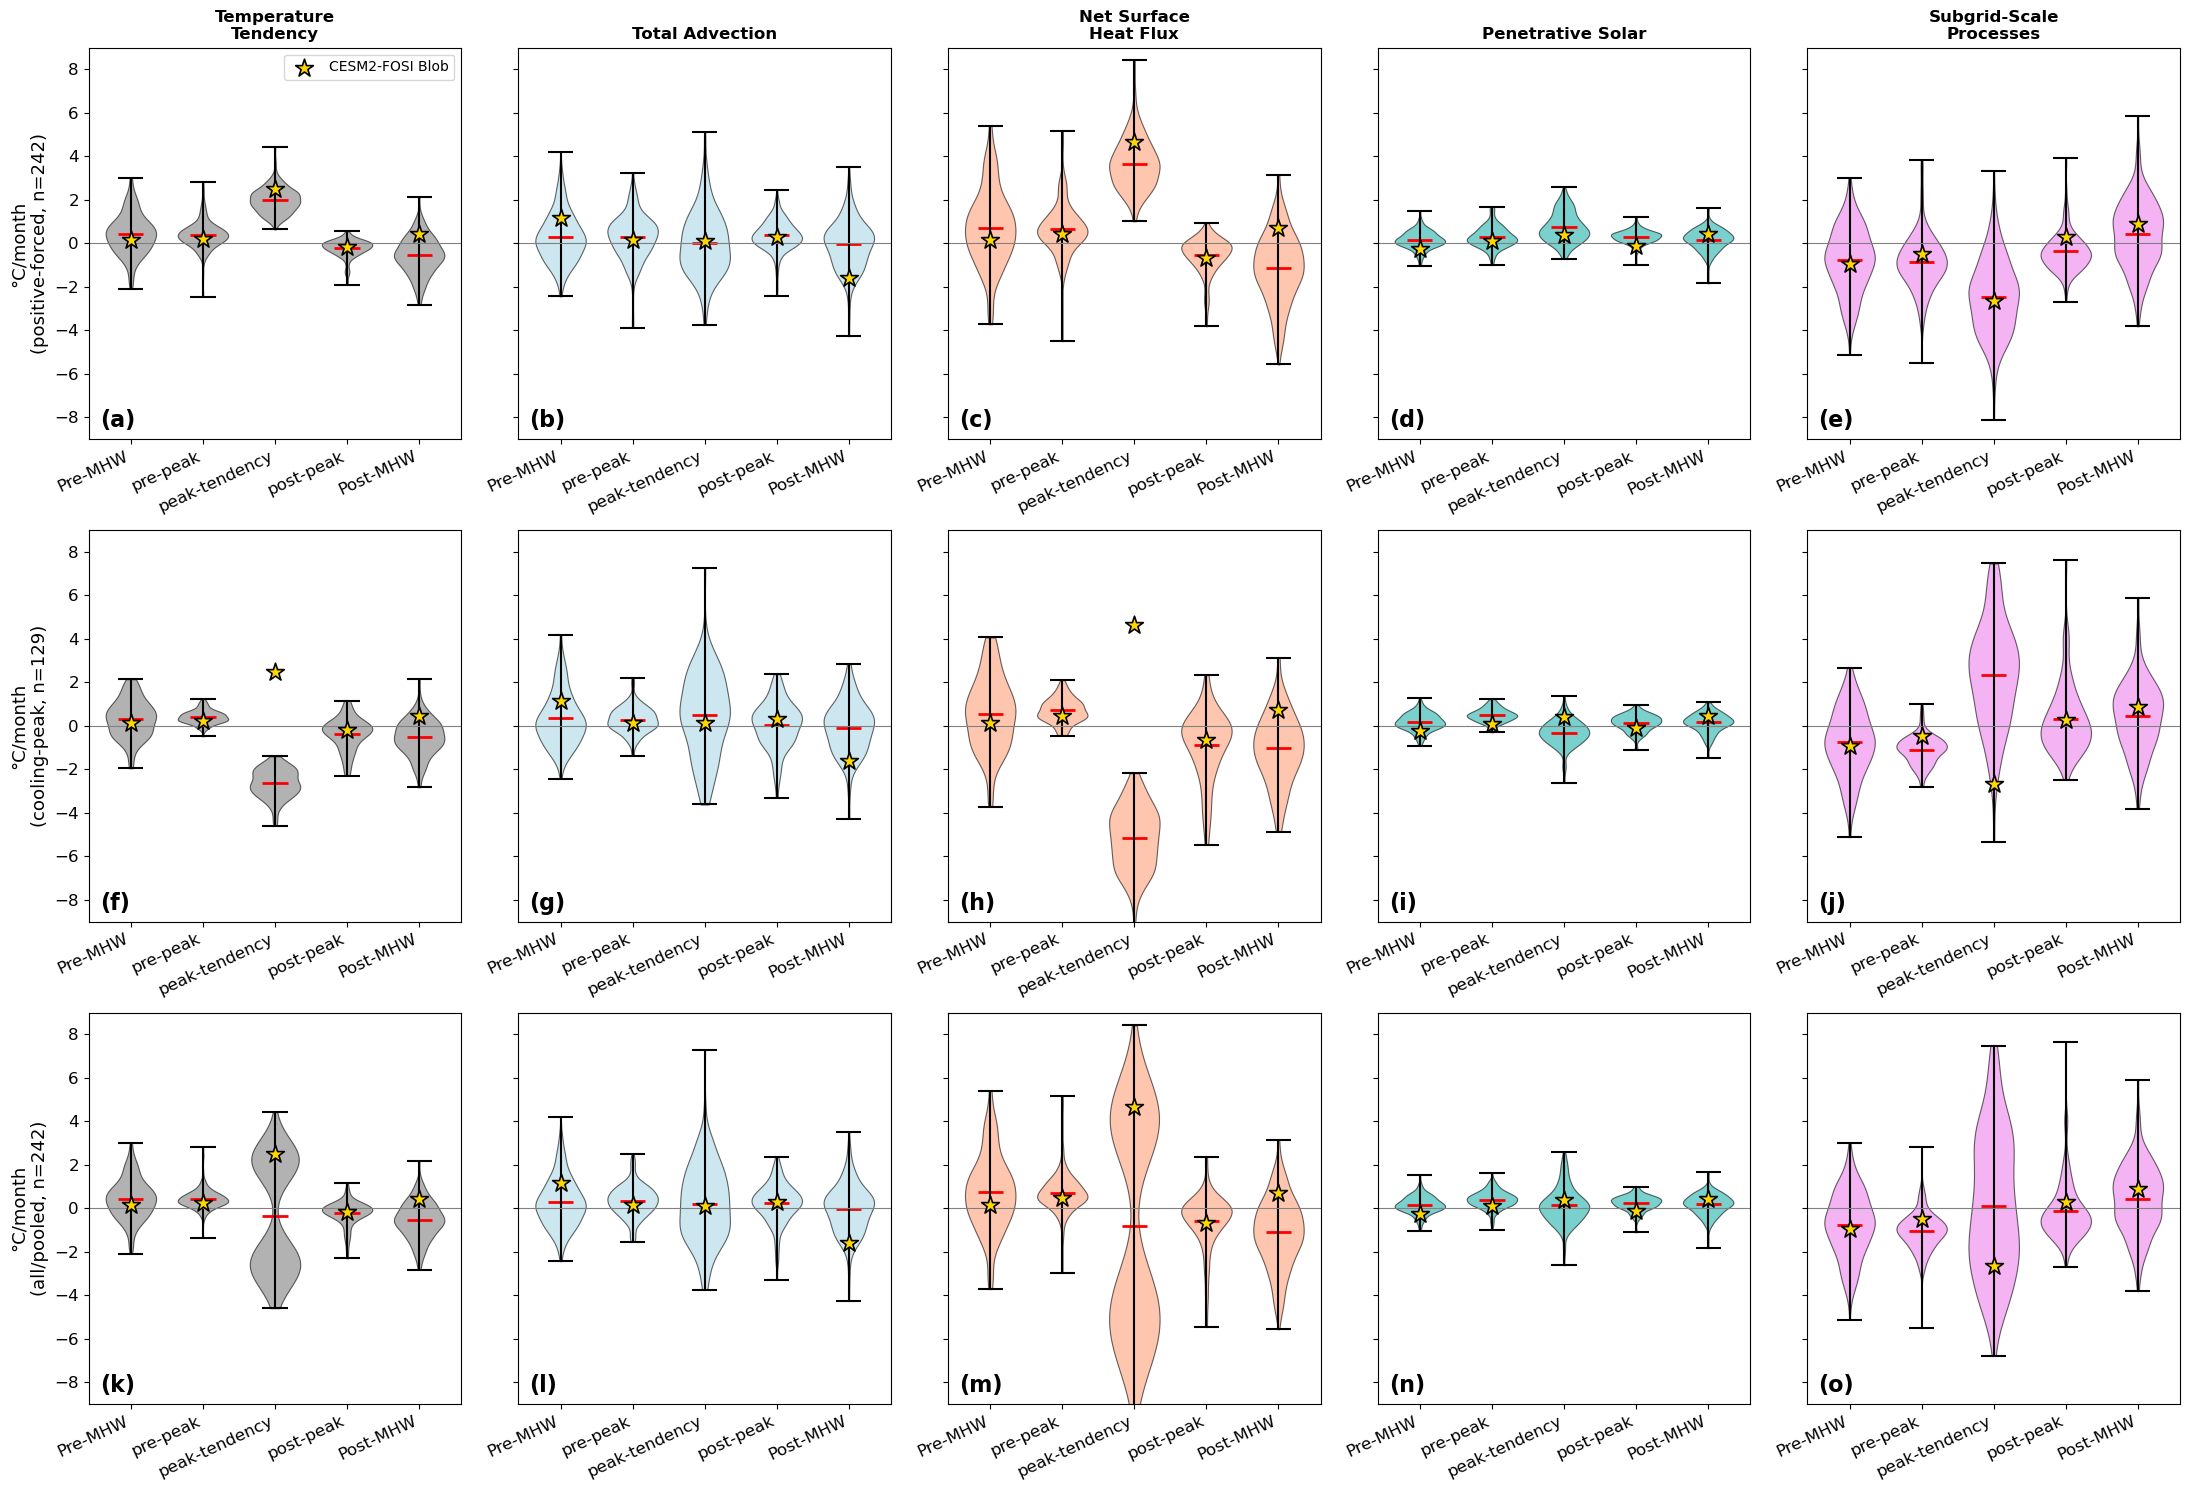

In [45]:
blob_values_all_phases = {
    term: {phase: fosi_phases_5[term][phase] for phase in PHASE_NAMES_5}
    for term in TERMS
}
for term in TERMS:
    blob_values_all_phases[term]['peak-tendency'] = {
        'TEND_TEMP': 2.49, 'TOT_ADV': 0.11, 'SHF_depth': 4.66, 'QSW_3D': 0.39, 'SUBGRID': -2.66
    }[term]

term_titles = {
    'TEND_TEMP': 'Temperature\nTendency', 'TOT_ADV': 'Total Advection',
    'SHF_depth': 'Net Surface\nHeat Flux', 'QSW_3D': 'Penetrative Solar', 'SUBGRID': 'Subgrid-Scale\nProcesses',
}
term_colors = {
    'TEND_TEMP': 'gray', 'TOT_ADV': 'lightblue',
    'SHF_depth': 'lightsalmon', 'QSW_3D': 'lightseagreen', 'SUBGRID': 'violet',
}
panel_letters_row1 = ['(a)', '(b)', '(c)', '(d)', '(e)']
panel_letters_row2 = ['(f)', '(g)', '(h)', '(i)', '(j)']
panel_letters_row3 = ['(k)', '(l)', '(m)', '(n)', '(o)']

fig, axes = plt.subplots(3, 5, figsize=(22, 15))

# --- Row 1: Positive-tendency-forced (n=242) ---
for ax, term, letter in zip(axes[0], TERMS, panel_letters_row1):
    plot_term_panel_violin_with_blob(ax, term, PHASE_NAMES_5, list(hb_phases_positive_only.keys()),
                                      hb_phases_positive_only, blob_values_all_phases[term],
                                      term_titles[term], term_colors[term])
    ax.text(0.03, 0.03, letter, transform=ax.transAxes, fontsize=16, fontweight='bold')
    if ax == axes[0, 0]:
        ax.set_ylabel(f'\u00b0C/month\n(positive-forced, n={len(hb_phases_positive_only)})', fontsize=13)
        ax.legend(fontsize=10, loc='upper right')
    else:
        ax.set_yticklabels([])

# --- Row 2: Cooling-peak (n=129) ---
for ax, term, letter in zip(axes[1], TERMS, panel_letters_row2):
    plot_term_panel_violin_with_blob(ax, term, PHASE_NAMES_5, cooling_keys, hb_phases_all,
                                      blob_values_all_phases[term], '', term_colors[term])
    ax.text(0.03, 0.03, letter, transform=ax.transAxes, fontsize=16, fontweight='bold')
    if ax == axes[1, 0]:
        ax.set_ylabel(f'\u00b0C/month\n(cooling-peak, n={len(cooling_keys)})', fontsize=13)
    else:
        ax.set_yticklabels([])

# --- Row 3: All / pooled (n=242) ---
for ax, term, letter in zip(axes[2], TERMS, panel_letters_row3):
    plot_term_panel_violin_with_blob(ax, term, PHASE_NAMES_5, keys_5phase, hb_phases_all,
                                      blob_values_all_phases[term], '', term_colors[term])
    ax.text(0.03, 0.03, letter, transform=ax.transAxes, fontsize=16, fontweight='bold')
    if ax == axes[2, 0]:
        ax.set_ylabel(f'\u00b0C/month\n(all/pooled, n={len(keys_5phase)})', fontsize=13)
    else:
        ax.set_yticklabels([])

plt.tight_layout()
plt.savefig('Figure_S_heat_budget_three_populations.png', dpi=300, bbox_inches='tight')
plt.show()